# PhaseCoder: Time-Varying RIR Training

End-to-end training pipeline using pre-generated time-varying RIR datasets:

- **Training data:** `tv_train_data/` — 100,000 clips (50% dynamic), time-varying RIRs
- **Evaluation data:** `tv_eval_data/` — 1,000 clips (100% dynamic), held-out evaluation set

Models trained:
1. **Baseline** — static-array assumption, ignores IMU (uses `tv_train_data` for train, `tv_eval_data` for eval)
2. **IMU-conditioned** — uses per-frame quaternions from time-varying RIR simulation

**Methodology:** Dementyev et al. 2026 — RIR-based synthesis, magnitude+phase STFT,
geometry-agnostic positional embeddings, transformer encoder, three classification heads.

## How to use this notebook

- Skip Sections 3–5 (dataset generation) — data already exists in `tv_train_data/` and `tv_eval_data/`.
- Run cells sequentially from Section 1 (Setup) → Section 2 (Config) → Section 6 (Dataset) → onward.
- All cells are GPU-aware.

## Required files in the same directory

- `PhaseCoder.py` — the model
- `tv_train_data/` — training clips + manifest
- `tv_eval_data/` — evaluation clips + manifest


## 1. Setup

Install dependencies and import everything we'll need.

In [1]:
# Install dependencies (skip if already installed)
# Uncomment the next line if running for the first time:
# !pip install torch numpy pyroomacoustics matplotlib

import os
import sys
import math
import json
import time
from pathlib import Path
from multiprocessing import Pool, cpu_count

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import pyroomacoustics as pra

# Import the PhaseCoder model and loss from your existing implementation
from PhaseCoder import PhaseCoder, PhaseCoderLoss

# ============================================================
# GPU verification — fail loudly if CUDA isn't working
# ============================================================
print("=" * 60)
print("GPU / CUDA Check")
print("=" * 60)

# Check if PyTorch was built with CUDA support
print(f"PyTorch version:        {torch.__version__}")
print(f"PyTorch CUDA support:   {torch.version.cuda}")
print(f"CUDA available:         {torch.cuda.is_available()}")

if not torch.cuda.is_available():
    print("\n❌ CUDA is NOT available. Possible reasons:")
    print("   1. PyTorch was installed without CUDA support (CPU-only build)")
    print("   2. No NVIDIA GPU is present on this machine")
    print("   3. NVIDIA drivers are not installed or out of date")
    print("\nTo fix:")
    print("   - Verify GPU exists: run !nvidia-smi in a cell")
    print("   - Reinstall PyTorch with CUDA support, e.g.:")
    print("     pip install torch --index-url https://download.pytorch.org/whl/cu124")
    raise RuntimeError("CUDA not available — refusing to continue on CPU.")

# CUDA is available — get details
device = torch.device("cuda")
gpu_count = torch.cuda.device_count()
gpu_idx = torch.cuda.current_device()
gpu_name = torch.cuda.get_device_name(gpu_idx)
gpu_props = torch.cuda.get_device_properties(gpu_idx)
gpu_mem_gb = gpu_props.total_memory / 1e9
gpu_capability = f"{gpu_props.major}.{gpu_props.minor}"

print(f"\n✓ CUDA is available")
print(f"  GPU count:            {gpu_count}")
print(f"  Active GPU:           [{gpu_idx}] {gpu_name}")
print(f"  Memory:               {gpu_mem_gb:.1f} GB")
print(f"  Compute capability:   {gpu_capability}")

# Functional test: actually run a tensor operation on the GPU
print(f"\nRunning GPU sanity check...")
try:
    x = torch.randn(1000, 1000, device=device)
    y = torch.randn(1000, 1000, device=device)
    z = x @ y
    torch.cuda.synchronize()  # wait for kernel to actually finish
    assert z.device.type == "cuda", f"Expected CUDA tensor, got {z.device}"
    del x, y, z
    torch.cuda.empty_cache()
    print(f"  ✓ GPU computation works correctly")
except Exception as e:
    print(f"  ❌ GPU computation failed: {e}")
    raise

# Check available memory before training starts
free_mem_gb = (gpu_props.total_memory - torch.cuda.memory_allocated()) / 1e9
print(f"  Free memory:          {free_mem_gb:.1f} GB")

if gpu_mem_gb < 6.0:
    print(f"\n⚠️  Warning: GPU has only {gpu_mem_gb:.1f} GB. "
          f"Consider reducing BATCH_SIZE if you hit OOM errors.")
elif gpu_mem_gb < 12.0:
    print(f"\n  Note: With {gpu_mem_gb:.1f} GB GPU, batch_size=32-64 is safe.")
else:
    print(f"\n  Plenty of GPU memory — batch_size=64-128 should work.")

print(f"\nUsing device: {device}")


GPU / CUDA Check
PyTorch version:        2.6.0+cu124
PyTorch CUDA support:   12.4
CUDA available:         True

✓ CUDA is available
  GPU count:            1
  Active GPU:           [0] NVIDIA GeForce RTX 4060 Laptop GPU
  Memory:               8.6 GB
  Compute capability:   8.9

Running GPU sanity check...
  ✓ GPU computation works correctly
  Free memory:          8.6 GB

  Note: With 8.6 GB GPU, batch_size=32-64 is safe.

Using device: cuda


## 2. Configuration

**This is the main knob you'll adjust.** Pick a preset based on how much time/compute you have:

| Preset | num_clips | Time on GPU | Time on CPU | Use for |
|--------|-----------|-------------|-------------|---------|
| Smoke test | 500 | ~5 min | ~30 min | Pipeline sanity check |
| Quick demo | 5,000 | ~30 min | ~3 hours | Initial results |
| Solid demo | 25,000 | ~2 hours | overnight | Presentation-ready |
| Full scale | 100,000 | ~6-9 hours | days | Serious results |

In [2]:
# ============================================================
# CONFIGURATION — adjust based on your time/compute budget
# ============================================================

# Dataset size
# Pre-generated dataset directories (data already exists — no generation step needed)
TRAIN_DIR = Path("./tv_train_data")   # 100k clips, 50% dynamic, time-varying RIRs
EVAL_DIR  = Path("./tv_eval_data")    # 1k clips, 100% dynamic, held-out evaluation set

# Checkpoint output paths
BASELINE_RUN_DIR = Path("./runs/tv_baseline")
IMU_RUN_DIR      = Path("./runs/tv_imu")
RESULTS_DIR      = Path("./eval_results_tv")

# Training hyperparameters
EPOCHS = 15                 # 15-30 typically; more data → fewer epochs needed
BATCH_SIZE = 128 if device.type == "cuda" else 16   # RTX 4060 8.6 GB handles 128-256 easily
LEARNING_RATE = 5e-4
WARMUP_EPOCHS = 2
# num_workers=0 loads data on the main thread — no multiprocessing, no Windows deadlock.
# Slightly slower I/O than workers>0 but guaranteed to start immediately.
NUM_DATALOADER_WORKERS = 0

# Random seed
SEED = 0

# Verify both dataset directories and report sizes
print("Dataset check:")
for d in [TRAIN_DIR, EVAL_DIR]:
    manifest_path = d / "manifest.json"
    if not manifest_path.exists():
        raise FileNotFoundError(f"Missing manifest: {manifest_path}")
    with open(manifest_path) as f:
        m = json.load(f)
    n_clips  = m.get("num_clips", len(m.get("clips", [])))
    frac_dyn = m.get("fraction_dynamic", "?")
    print(f"  {d.name}: {n_clips:,} clips  (fraction_dynamic={frac_dyn})")

print(f"\nConfiguration:")
print(f"  TRAIN_DIR:          {TRAIN_DIR}")
print(f"  EVAL_DIR:           {EVAL_DIR}")
print(f"  EPOCHS:             {EPOCHS}")
print(f"  BATCH_SIZE:         {BATCH_SIZE}")
print(f"  LEARNING_RATE:      {LEARNING_RATE}")
print(f"  Dataloader workers: {NUM_DATALOADER_WORKERS} (main-thread, no Windows deadlock)")
print(f"  Baseline output:    {BASELINE_RUN_DIR}")
print(f"  IMU output:         {IMU_RUN_DIR}")


Dataset check:
  tv_train_data: 500,000 clips  (fraction_dynamic=0.5)
  tv_eval_data: 10,000 clips  (fraction_dynamic=1.0)

Configuration:
  TRAIN_DIR:          tv_train_data
  EVAL_DIR:           tv_eval_data
  EPOCHS:             15
  BATCH_SIZE:         128
  LEARNING_RATE:      0.0005
  Dataloader workers: 0 (main-thread, no Windows deadlock)
  Baseline output:    runs\tv_baseline
  IMU output:         runs\tv_imu


## 2b. Dataset Diagnostics

Quick sanity-check on the first 1,000 training clips.  
Checks for NaN/Inf audio, silent/extreme clips, and invalid IMU quaternions.  
Run this before training to confirm the data is clean.

In [3]:
import numpy as np, json

N_CHECK = 1_000  # number of clips to sample — fast but representative

with open(TRAIN_DIR / "manifest.json") as f:
    _manifest = json.load(f)

all_files = [c["filename"] for c in _manifest["clips"]]
sample = all_files[:N_CHECK]

audio_issues, quat_issues = [], []

for i, filename in enumerate(sample):
    if i % 100 == 0:
        print(f"  Checking {i}/{N_CHECK}...", flush=True)
    data = np.load(TRAIN_DIR / filename)
    audio = data["audio"]

    has_nan    = bool(np.any(np.isnan(audio)))
    has_inf    = bool(np.any(np.isinf(audio)))
    is_silent  = float(np.abs(audio).max()) < 1e-6
    is_extreme = float(np.abs(audio).max()) > 10.0

    if has_nan or has_inf or is_silent or is_extreme:
        audio_issues.append({
            "file": filename, "nan": has_nan, "inf": has_inf,
            "silent": is_silent, "extreme": is_extreme,
            "is_dynamic": bool(data["is_dynamic"]),
            "max_val": float(np.abs(audio).max()),
        })

    if data["is_dynamic"]:
        quats = data["imu_quats"]
        q_nan = bool(np.any(np.isnan(quats)))
        q_inf = bool(np.any(np.isinf(quats)))
        norms = np.linalg.norm(quats, axis=-1)
        non_unit = bool(np.any(np.abs(norms - 1.0) > 0.1))
        if q_nan or q_inf or non_unit:
            quat_issues.append({
                "file": filename, "nan": q_nan, "inf": q_inf,
                "non_unit": non_unit,
                "norm_range": f"{norms.min():.3f}-{norms.max():.3f}",
            })

print(f"\n=== tv_train_data ({N_CHECK} clips checked) ===")
print(f"  Audio issues : {len(audio_issues)} ({100*len(audio_issues)/N_CHECK:.1f}%)")
print(f"  Quat  issues : {len(quat_issues)}")
print()
for p in audio_issues[:20]:
    print("  AUDIO:", p)
for p in quat_issues[:20]:
    print("  QUAT: ", p)
if not audio_issues and not quat_issues:
    print("  All clear — no data corruption detected in this sample.")


  Checking 0/1000...
  Checking 100/1000...
  Checking 200/1000...
  Checking 300/1000...
  Checking 400/1000...
  Checking 500/1000...
  Checking 600/1000...
  Checking 700/1000...
  Checking 800/1000...
  Checking 900/1000...

=== tv_train_data (1000 clips checked) ===
  Audio issues : 1 (0.1%)
  Quat  issues : 0

  AUDIO: {'file': 'clip_000195.npz', 'nan': False, 'inf': False, 'silent': True, 'extreme': False, 'is_dynamic': False, 'max_val': 8.04779290319857e-07}


## 2c. Training History: NaN / fp16 Overflow Check

Scans saved `history.json` files from both training runs to find when NaN first appeared.  
A sudden NaN that persists is the signature of mixed-precision (fp16) overflow.  
Run this cell after training has completed (or been interrupted).

In [4]:
import json, math

for run_dir, label in [(BASELINE_RUN_DIR, "Baseline"), (IMU_RUN_DIR, "IMU")]:
    hist_path = run_dir / "history.json"
    print(f"\n=== {label} ({hist_path}) ===")
    try:
        with open(hist_path) as f:
            h = json.load(f)
        train_losses = h.get("train_loss", [])
        eval_losses  = h.get("eval_loss", [])
        first_nan_epoch = None
        for i, (tl, el) in enumerate(zip(train_losses, eval_losses)):
            tl_nan = tl is None or (isinstance(tl, float) and math.isnan(tl))
            el_nan = el is None or (isinstance(el, float) and math.isnan(el))
            tl_str = "NaN    " if tl_nan else f"{tl:.4f}"
            el_str = "NaN    " if el_nan else f"{el:.4f}"
            marker = " <<< NaN first appears" if (tl_nan or el_nan) and first_nan_epoch is None else ""
            if (tl_nan or el_nan) and first_nan_epoch is None:
                first_nan_epoch = i + 1
            print(f"  Epoch {i+1:2d}: train_loss={tl_str}  eval_loss={el_str}{marker}")
        if first_nan_epoch:
            print(f"\n  *** fp16 overflow detected — NaN first appeared at epoch {first_nan_epoch} ***")
            print(f"  Fix: disable AMP, or add gradient clipping / lower LR before that epoch.")
        else:
            print(f"\n  No NaN detected across {len(train_losses)} epochs — losses look clean.")
    except FileNotFoundError:
        print(f"  history.json not found — has this run completed yet?")
    except Exception as e:
        print(f"  Error reading history: {e}")



=== Baseline (runs\tv_baseline\history.json) ===
  Epoch  1: train_loss=6.3856  eval_loss=6.1109
  Epoch  2: train_loss=6.1599  eval_loss=5.9091
  Epoch  3: train_loss=5.6743  eval_loss=4.7829
  Epoch  4: train_loss=5.0458  eval_loss=4.4385
  Epoch  5: train_loss=4.7511  eval_loss=4.3589
  Epoch  6: train_loss=4.6169  eval_loss=4.1792
  Epoch  7: train_loss=4.5307  eval_loss=4.1767
  Epoch  8: train_loss=4.4559  eval_loss=4.0912
  Epoch  9: train_loss=4.3841  eval_loss=4.0447
  Epoch 10: train_loss=4.3157  eval_loss=4.0518
  Epoch 11: train_loss=4.2504  eval_loss=3.9664
  Epoch 12: train_loss=4.1872  eval_loss=3.9247
  Epoch 13: train_loss=4.1384  eval_loss=3.8873
  Epoch 14: train_loss=4.0990  eval_loss=3.8967
  Epoch 15: train_loss=4.0774  eval_loss=3.8683

  No NaN detected across 15 epochs — losses look clean.

=== IMU (runs\tv_imu\history.json) ===
  Epoch  1: train_loss=6.4057  eval_loss=6.0603
  Epoch  2: train_loss=6.0327  eval_loss=5.8345
  Epoch  3: train_loss=5.5458  eval_l

## 2d. Checkpoint Inspection: Epoch and Weight Validity

Shows which epoch each `best.pt` checkpoint was saved from and whether the stored weights contain any NaN or Inf values.

In [5]:
import torch

for run_dir, label in [(BASELINE_RUN_DIR, "Baseline"), (IMU_RUN_DIR, "IMU")]:
    ckpt_path = run_dir / "best.pt"
    print(f"\n=== {label} ({ckpt_path}) ===")
    try:
        ckpt = torch.load(ckpt_path, map_location="cpu", weights_only=False)
        epoch = ckpt.get("epoch", "unknown")
        # epoch is stored 0-indexed, display as 1-indexed
        epoch_display = epoch + 1 if isinstance(epoch, int) else epoch
        print(f"  Stored epoch    : {epoch_display}")
        print(f"  eval_loss       : {ckpt.get('eval_loss', ckpt.get('val_loss', 'missing'))}")
        print(f"  eval_az_acc     : {ckpt.get('eval_az_acc', 'missing')}")
        state_dict = ckpt["model_state_dict"]
        nan_keys, inf_keys = [], []
        for key, tensor in state_dict.items():
            if torch.isnan(tensor).any(): nan_keys.append(key)
            if torch.isinf(tensor).any(): inf_keys.append(key)
        if nan_keys:
            print(f"  NaN in weights  : {nan_keys}")
        if inf_keys:
            print(f"  Inf in weights  : {inf_keys}")
        if not nan_keys and not inf_keys:
            print(f"  Weights         : all valid (no NaN or Inf)")
    except FileNotFoundError:
        print(f"  best.pt not found — has this run completed yet?")
    except Exception as e:
        print(f"  Error: {e}")



=== Baseline (runs\tv_baseline\best.pt) ===
  best.pt not found — has this run completed yet?

=== IMU (runs\tv_imu\best.pt) ===
  Stored epoch    : 15
  eval_loss       : 3.8731204859818082
  eval_az_acc     : 0.4786
  Weights         : all valid (no NaN or Inf)


## 3. PhaseCoder constants and helper functions

These match the paper exactly: 16 kHz, 250 ms clips, STFT with 256 win / 128 hop,
38 azimuth bins / 18 elevation bins / 13 distance bins.

In [6]:
# Constants matching PhaseCoder paper
SAMPLE_RATE = 16000
CLIP_DURATION_S = 0.25
NUM_SAMPLES = int(SAMPLE_RATE * CLIP_DURATION_S)  # 4000
N_FFT = 256
HOP_LENGTH = 128
NUM_FRAMES = 32  # torch.stft(center=True) on 4000 samples → 32 frames

NUM_AZIMUTH = 38
NUM_ELEVATION = 18
NUM_DISTANCE = 13

DISTANCE_BIN_EDGES = np.array([0.4, 0.6, 0.8, 1.0, 1.3, 1.6, 2.0, 2.5, 3.0, 3.5, 4.5, 5.5, 7.0])

print(f"Audio config: {SAMPLE_RATE}Hz, {CLIP_DURATION_S*1000:.0f}ms clips, {NUM_FRAMES} STFT frames")
print(f"Label space: {NUM_AZIMUTH} azimuth × {NUM_ELEVATION} elevation × {NUM_DISTANCE} distance bins")


Audio config: 16000Hz, 250ms clips, 32 STFT frames
Label space: 38 azimuth × 18 elevation × 13 distance bins


In [7]:
def generate_source_signal(duration_s: float, rng: np.random.Generator) -> np.ndarray:
    """Synthetic harmonic source with broadband content for STFT."""
    n = int(SAMPLE_RATE * duration_s)
    t = np.arange(n) / SAMPLE_RATE

    f0 = rng.uniform(120, 350)
    signal = np.zeros(n)
    for harmonic in range(1, 7):
        amp = rng.uniform(0.3, 1.0) / harmonic
        phase = rng.uniform(0, 2 * np.pi)
        signal += amp * np.sin(2 * np.pi * f0 * harmonic * t + phase)

    am = 0.5 + 0.5 * np.sin(2 * np.pi * rng.uniform(2, 6) * t)
    signal *= am

    fade = int(0.015 * SAMPLE_RATE)
    envelope = np.ones(n)
    envelope[:fade] = np.linspace(0, 1, fade)
    envelope[-fade:] = np.linspace(1, 0, fade)
    signal *= envelope

    signal /= max(np.max(np.abs(signal)), 1e-8)
    return (signal * 0.8).astype(np.float32)


def generate_random_array(rng: np.random.Generator) -> np.ndarray:
    """Random circular mic array with 4-8 mics, varying radius."""
    num_mics = rng.integers(4, 9)
    radius = rng.uniform(0.04, 0.10)
    angles = np.linspace(0, 2 * np.pi, num_mics, endpoint=False)
    angles += rng.uniform(-0.1, 0.1, size=num_mics)
    coords = np.stack([
        radius * np.cos(angles),
        radius * np.sin(angles),
        rng.uniform(-0.01, 0.01, size=num_mics),
    ], axis=-1)
    return coords.astype(np.float32)


def spherical_to_cartesian(az_deg, el_deg, distance):
    az = math.radians(az_deg); el = math.radians(el_deg)
    return np.array([
        distance * math.cos(el) * math.cos(az),
        distance * math.cos(el) * math.sin(az),
        distance * math.sin(el),
    ], dtype=np.float32)


def discretize_labels(az_deg, el_deg, dist):
    az_bin = min(int(az_deg / 360 * NUM_AZIMUTH), NUM_AZIMUTH - 1)
    el_bin = min(max(int((el_deg + 90) / 180 * NUM_ELEVATION), 0), NUM_ELEVATION - 1)
    dist_bin = min(int(np.searchsorted(DISTANCE_BIN_EDGES, dist)), NUM_DISTANCE - 1)
    return {"azimuth": az_bin, "elevation": el_bin, "distance": dist_bin}


def axis_angle_to_quaternion(axis, angle_rad):
    axis = axis / (np.linalg.norm(axis) + 1e-12)
    half = angle_rad / 2
    s = math.sin(half)
    return np.array([math.cos(half), axis[0]*s, axis[1]*s, axis[2]*s], dtype=np.float32)


def quaternion_to_rotation_matrix(q):
    w, x, y, z = q / (np.linalg.norm(q) + 1e-12)
    return np.array([
        [1-2*(y*y+z*z), 2*(x*y-z*w), 2*(x*z+y*w)],
        [2*(x*y+z*w), 1-2*(x*x+z*z), 2*(y*z-x*w)],
        [2*(x*z-y*w), 2*(y*z+x*w), 1-2*(x*x+y*y)],
    ], dtype=np.float32)

print("Helper functions defined.")


Helper functions defined.


## 4. Clip simulation function

This simulates a single multichannel audio clip using pyroomacoustics' image-source method.
For dynamic clips, it generates per-frame quaternions reflecting the array's rotation trajectory.

In [ ]:
def simulate_clip(mic_coords, source_az_deg, source_el_deg, source_distance,
                  rng, rotation_rate_dps=0.0, rotation_axis=None):
    """Simulate one spatial audio clip with optional array rotation."""
    C = mic_coords.shape[0]

    # Random shoebox room
    room_dim = np.array([
        rng.uniform(4.0, 8.0), rng.uniform(3.0, 6.0), rng.uniform(2.5, 3.5),
    ])
    rt60 = rng.uniform(0.15, 0.35)
    e_absorption, max_order = pra.inverse_sabine(rt60, room_dim)
    room = pra.ShoeBox(room_dim, fs=SAMPLE_RATE,
                       materials=pra.Material(e_absorption), max_order=max_order)

    # Place array centroid at head height with margins
    centroid = np.array([
        rng.uniform(1.0, room_dim[0] - 1.0),
        rng.uniform(1.0, room_dim[1] - 1.0),
        rng.uniform(1.2, 1.8),
    ])

    # Compute IMU quaternions for dynamic clips
    if rotation_rate_dps > 0:
        if rotation_axis is None:
            rotation_axis = np.array([0, 0, 1], dtype=np.float32)
        rotation_axis = rotation_axis / np.linalg.norm(rotation_axis)
        frame_times = (np.arange(NUM_FRAMES) * HOP_LENGTH + N_FFT/2) / SAMPLE_RATE
        angles_rad = np.radians(rotation_rate_dps * frame_times)
        imu_quats = np.stack([axis_angle_to_quaternion(rotation_axis, a)
                               for a in angles_rad], axis=0)
        canonical_idx = NUM_FRAMES // 2
        R_canonical = quaternion_to_rotation_matrix(imu_quats[canonical_idx])
        mic_coords_rotated = mic_coords @ R_canonical.T
    else:
        imu_quats = None
        mic_coords_rotated = mic_coords

    mic_world = (centroid[None, :] + mic_coords_rotated).T
    room.add_microphone_array(pra.MicrophoneArray(mic_world, fs=SAMPLE_RATE))

    source_offset = spherical_to_cartesian(source_az_deg, source_el_deg, source_distance)
    source_world = np.clip(centroid + source_offset, 0.2, room_dim - 0.2)

    src_signal = generate_source_signal(CLIP_DURATION_S * 2.0, rng)
    room.add_source(source_world, signal=src_signal)
    room.simulate()

    sim_audio = room.mic_array.signals
    T_sim = sim_audio.shape[1]
    if T_sim >= NUM_SAMPLES:
        start = max(0, int(0.005 * SAMPLE_RATE))
        if start + NUM_SAMPLES > T_sim:
            start = T_sim - NUM_SAMPLES
        audio = sim_audio[:, start:start + NUM_SAMPLES]
    else:
        audio = np.zeros((C, NUM_SAMPLES), dtype=np.float32)
        audio[:, :T_sim] = sim_audio

    peak = np.max(np.abs(audio))
    if peak > 1e-8:
        audio = (audio / peak * 0.7).astype(np.float32)

    return audio.astype(np.float32), imu_quats

# Quick test of simulation
test_rng = np.random.default_rng(42)
test_mics = generate_random_array(test_rng)
test_audio, test_imu = simulate_clip(test_mics, 90.0, 0.0, 1.5, test_rng,
                                       rotation_rate_dps=200.0,
                                       rotation_axis=np.array([0, 0, 1.0]))
print(f"Test clip: audio shape {test_audio.shape}, IMU shape {test_imu.shape}")
print(f"Audio range: [{test_audio.min():.3f}, {test_audio.max():.3f}]")


## 5. Generate the dataset (parallel)

This is the slowest cell. Time depends on `NUM_CLIPS` and number of CPU cores.

**While this runs**, you can keep an eye on the progress output. It's safe to interrupt
(Kernel → Interrupt) if you want to test downstream cells with whatever clips have been
generated so far — the manifest is built from completed clips.

In [ ]:
def _generate_one_clip_worker(args):
    """Worker for multiprocessing pool."""
    clip_idx, output_dir_str, seed, fraction_dynamic = args
    output_dir = Path(output_dir_str)
    rng = np.random.default_rng(seed + clip_idx)

    try:
        mic_coords = generate_random_array(rng)
        source_az = float(rng.uniform(0, 360))
        source_el = float(rng.uniform(-30, 30))
        source_dist = float(np.exp(rng.uniform(np.log(0.5), np.log(5.0))))

        is_dynamic = rng.random() < fraction_dynamic
        if is_dynamic:
            rotation_rate = float(rng.choice([30, 60, 100, 150, 200, 300, 450])
                                  * rng.choice([-1, 1]))
            axis = np.array([
                rng.uniform(-0.3, 0.3), rng.uniform(-0.3, 0.3),
                rng.choice([-1, 1]) * rng.uniform(0.7, 1.0),
            ], dtype=np.float32)
            axis = axis / np.linalg.norm(axis)
        else:
            rotation_rate = 0.0
            axis = None

        audio, imu_quats = simulate_clip(
            mic_coords, source_az, source_el, source_dist, rng,
            rotation_rate_dps=abs(rotation_rate) if is_dynamic else 0.0,
            rotation_axis=axis)

        labels = discretize_labels(source_az, source_el, source_dist)
        clip_path = output_dir / f"clip_{clip_idx:06d}.npz"
        save_kwargs = {
            "audio": audio, "mic_coords": mic_coords,
            "azimuth_class": np.int64(labels["azimuth"]),
            "elevation_class": np.int64(labels["elevation"]),
            "distance_class": np.int64(labels["distance"]),
            "azimuth_deg": np.float32(source_az),
            "elevation_deg": np.float32(source_el),
            "distance_m": np.float32(source_dist),
            "is_dynamic": np.bool_(is_dynamic),
            "rotation_rate_dps": np.float32(rotation_rate),
        }
        if is_dynamic:
            save_kwargs["imu_quats"] = imu_quats
        np.savez_compressed(clip_path, **save_kwargs)

        return {
            "filename": clip_path.name, "is_dynamic": bool(is_dynamic),
            "rotation_rate_dps": float(rotation_rate),
            "azimuth_deg": float(source_az), "elevation_deg": float(source_el),
            "distance_m": float(source_dist), "num_mics": int(mic_coords.shape[0]),
        }
    except Exception:
        return None


In [ ]:
# Run dataset generation
DATA_DIR.mkdir(parents=True, exist_ok=True)

print(f"Generating {NUM_CLIPS:,} clips with {NUM_GENERATION_WORKERS} workers...")
print(f"Output: {DATA_DIR}")
print("-" * 60)

work_args = [(i, str(DATA_DIR), SEED, FRACTION_DYNAMIC) for i in range(NUM_CLIPS)]

start_time = time.time()
successful = []
failed = 0

# Note: in Jupyter, we use a Pool with the worker function defined at module scope.
# If running interactively and getting pickle errors, restart kernel and re-run.
with Pool(processes=NUM_GENERATION_WORKERS) as pool:
    for i, result in enumerate(pool.imap_unordered(_generate_one_clip_worker,
                                                     work_args, chunksize=16)):
        if result is not None:
            successful.append(result)
        else:
            failed += 1

        if (i + 1) % max(1, NUM_CLIPS // 20) == 0 or (i + 1) == NUM_CLIPS:
            elapsed = time.time() - start_time
            rate = (i + 1) / max(elapsed, 0.001)
            eta_min = (NUM_CLIPS - i - 1) / max(rate, 0.001) / 60
            print(f"  [{i+1:6d}/{NUM_CLIPS}] {100*(i+1)/NUM_CLIPS:5.1f}% | "
                  f"{rate:.1f} clips/sec | ETA: {eta_min:.1f} min")

total_min = (time.time() - start_time) / 60
print(f"\n✓ Generated {len(successful):,} clips ({failed} failed) in {total_min:.1f} min")

# Sort and split
successful.sort(key=lambda c: c["filename"])
rng = np.random.default_rng(SEED + 999_999)
n_val = int(len(successful) * VAL_FRACTION)
val_indices = set(rng.choice(len(successful), size=n_val, replace=False).tolist())

manifest = {
    "num_clips": len(successful),
    "fraction_dynamic": FRACTION_DYNAMIC,
    "sample_rate": SAMPLE_RATE,
    "num_frames": NUM_FRAMES,
    "num_azimuth": NUM_AZIMUTH,
    "num_elevation": NUM_ELEVATION,
    "num_distance": NUM_DISTANCE,
    "clips": successful,
    "train_filenames": [c["filename"] for i, c in enumerate(successful) if i not in val_indices],
    "val_filenames": [c["filename"] for i, c in enumerate(successful) if i in val_indices],
}

with open(DATA_DIR / "manifest.json", "w") as f:
    json.dump(manifest, f, indent=2)

print(f"  Train: {len(manifest['clips']):,}")

# Statistics
dyn_count = sum(1 for c in successful if c["is_dynamic"])
print(f"\nStatistics:")
print(f"  Static:  {len(successful) - dyn_count:,}")
print(f"  Dynamic: {dyn_count:,}")


## 6. PyTorch Dataset and DataLoader

Custom collate function pads variable mic counts to the max in each batch.

In [10]:
class TvDataset(Dataset):
    """Dataset for time-varying RIR clips (tv_train_data / tv_eval_data).

    Every clip has imu_quats always present (identity quaternions for static clips).
    When use_imu=False, imu_quats is returned as None so the model takes the static path.
    """
    def __init__(self, data_dir, filenames, use_imu):
        self.data_dir = data_dir
        self.filenames = filenames
        self.use_imu = use_imu

    def __len__(self):
        return len(self.filenames)

    def __getitem__(self, idx):
        data = np.load(self.data_dir / self.filenames[idx])
        audio      = torch.from_numpy(data["audio"]).float()       # (C, T)
        mic_coords = torch.from_numpy(data["mic_coords"]).float()  # (C, 3)
        labels = {
            "azimuth":   int(data["azimuth_class"]),
            "elevation": int(data["elevation_class"]),
            "distance":  int(data["distance_class"]),
        }
        # imu_quats is always stored in tv_rir clips (identity for static)
        imu_quats = torch.from_numpy(data["imu_quats"]).float() if self.use_imu else None
        return {
            "audio": audio, "mic_coords": mic_coords, "imu_quats": imu_quats,
            "labels": labels, "is_dynamic": bool(data["is_dynamic"]),
            "rotation_rate_dps": float(data["rotation_rate_dps"]),
        }

# Keep ToyDataset as alias for any cells that still reference it
ToyDataset = TvDataset


def collate_fn(batch):
    max_mics = max(item["mic_coords"].shape[0] for item in batch)
    B = len(batch)
    T = batch[0]["audio"].shape[-1]
    audio = torch.zeros(B, max_mics, T)
    mic_coords = torch.zeros(B, max_mics, 3)
    has_imu = batch[0]["imu_quats"] is not None
    imu_quats = torch.zeros(B, batch[0]["imu_quats"].shape[0], 4) if has_imu else None
    for i, item in enumerate(batch):
        c = item["audio"].shape[0]
        audio[i, :c] = item["audio"]
        mic_coords[i, :c] = item["mic_coords"]
        if c < max_mics:
            mic_coords[i, c:] = item["mic_coords"].mean(dim=0)
        if has_imu:
            imu_quats[i] = item["imu_quats"]
    labels = {k: torch.tensor([item["labels"][k] for item in batch], dtype=torch.long)
              for k in ["azimuth", "elevation", "distance"]}
    return {
        "audio": audio, "mic_coords": mic_coords, "imu_quats": imu_quats,
        "labels": labels,
        "is_dynamic": [item["is_dynamic"] for item in batch],
        "rotation_rate_dps": [item["rotation_rate_dps"] for item in batch],
    }

print("Dataset class defined.")


Dataset class defined.


## 7. Training loop

Single function used to train both baseline and IMU models, parameterized by `use_imu`.
Includes warmup + cosine LR schedule, gradient clipping, and mixed-precision on GPU.

In [ ]:
def train_model(use_imu: bool, output_dir: Path, train_manifest, eval_manifest,
                epochs=EPOCHS, batch_size=BATCH_SIZE, lr=LEARNING_RATE):
    """Train PhaseCoder on tv_train_data, evaluate on tv_eval_data."""
    output_dir.mkdir(parents=True, exist_ok=True)
    use_amp = device.type == "cuda"

    # Use ALL clips in tv_train_data for training — the manifest's baked-in
    # train_filenames/val_filenames split is intentionally ignored so the full
    # 100k dataset is used. tv_eval_data is the sole evaluation set.
    train_files = [c["filename"] for c in train_manifest["clips"]]
    eval_files  = [c["filename"] for c in eval_manifest["clips"]]

    train_ds = TvDataset(TRAIN_DIR, train_files, use_imu=use_imu)
    eval_ds  = TvDataset(EVAL_DIR,  eval_files,  use_imu=use_imu)

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True,
                              collate_fn=collate_fn, num_workers=NUM_DATALOADER_WORKERS,
                              drop_last=True, pin_memory=use_amp)
    val_loader   = None  # no val split — tv_eval_data is the evaluation set
    eval_loader  = DataLoader(eval_ds, batch_size=batch_size, shuffle=False,
                              collate_fn=collate_fn, num_workers=NUM_DATALOADER_WORKERS,
                              pin_memory=use_amp)

    # ffn_expansion=4 matches the paper's 4× feedforward and gives the GPU more
    # compute per batch, reducing the fraction of time it spends idle waiting for data.
    model = PhaseCoder(ffn_expansion=4).to(device)

    # torch.compile fuses GPU kernels (requires PyTorch 2.x). The first epoch is
    # slightly slower due to tracing; subsequent epochs are faster.
    #if device.type == "cuda":
        #model = torch.compile(model)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)

    def lr_lambda(epoch):
        if epoch < WARMUP_EPOCHS:
            return (epoch + 1) / WARMUP_EPOCHS
        progress = (epoch - WARMUP_EPOCHS) / max(1, epochs - WARMUP_EPOCHS)
        return 0.5 * (1 + np.cos(np.pi * progress))

    scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)
    criterion = PhaseCoderLoss()
    scaler = torch.amp.GradScaler("cuda") if use_amp else None

    history = {
        "train_loss": [], "eval_loss": [],
        "eval_az_acc": [], "eval_el_acc": [], "eval_dist_acc": [],
    }
    best_eval = float("inf")
    overall_start = time.time()

    n_params = sum(p.numel() for p in model.parameters())
    n_train_batches = len(train_loader)
    log_every = max(1, n_train_batches // 10)

    label = "IMU" if use_imu else "baseline"
    print(f"{'='*60}")
    print(f"Training {label} model")
    print(f"{'='*60}")
    print(f"  Train:  {len(train_ds):,} clips ({n_train_batches} batches/epoch)  [{TRAIN_DIR.name}]")
    print(f"  Eval:   {len(eval_ds):,} clips  [{EVAL_DIR.name}]")
    print(f"  Params: {n_params/1e6:.2f}M  |  batch={batch_size}  |  lr={lr}  |  epochs={epochs}")
    if device.type == "cuda":
        print(f"  AMP fp16  |  ffn_expansion=4")
    print(f"{'='*60}")
    sys.stdout.flush()

    for epoch in range(epochs):
        model.train()
        train_losses = []
        running_loss = 0.0
        epoch_start = time.time()

        for batch_idx, batch in enumerate(train_loader):
            audio = batch["audio"].to(device, non_blocking=True)
            mic_coords = batch["mic_coords"].to(device, non_blocking=True)
            imu = batch["imu_quats"].to(device, non_blocking=True) if (use_imu and batch["imu_quats"] is not None) else None
            targets = {k: v.to(device, non_blocking=True) for k, v in batch["labels"].items()}

            optimizer.zero_grad(set_to_none=True)
            if use_amp:
                with torch.amp.autocast("cuda", dtype=torch.float16):
                    out = model(audio, mic_coords, imu_orientations=imu)
                    losses = criterion(out, targets)
                scaler.scale(losses["loss"]).backward()
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                scaler.step(optimizer)
                scaler.update()
            else:
                out = model(audio, mic_coords, imu_orientations=imu)
                losses = criterion(out, targets)
                losses["loss"].backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()

            loss_val = losses["loss"].item()
            train_losses.append(loss_val)
            running_loss += loss_val

            # Print within-epoch batch progress
            if (batch_idx + 1) % log_every == 0 or (batch_idx + 1) == n_train_batches:
                elapsed = time.time() - epoch_start
                batches_done = batch_idx + 1
                avg_so_far = running_loss / batches_done
                eta_s = elapsed / batches_done * (n_train_batches - batches_done)
                clips_done = batches_done * batch_size
                clips_total = n_train_batches * batch_size
                current_lr = scheduler.get_last_lr()[0]
                print(f"  Epoch {epoch+1:2d}/{epochs} | "
                      f"batch {batches_done:4d}/{n_train_batches} "
                      f"({clips_done:,}/{clips_total:,} clips) | "
                      f"loss {avg_so_far:.4f} | "
                      f"lr {current_lr:.2e} | "
                      f"ETA {eta_s:.0f}s")
                sys.stdout.flush()

        scheduler.step()
        model.eval()

        def _run_eval_split(loader):
            """Run one evaluation pass, return (avg_loss, az_acc, el_acc, dist_acc)."""
            if loader is None:
                return float("nan"), 0.0, 0.0, 0.0
            ev_losses = []
            az_c = el_c = dist_c = tot = 0
            with torch.no_grad():
                for batch in loader:
                    audio_b      = batch["audio"].to(device, non_blocking=True)
                    mc_b         = batch["mic_coords"].to(device, non_blocking=True)
                    imu_b        = batch["imu_quats"].to(device, non_blocking=True) if (use_imu and batch["imu_quats"] is not None) else None
                    targets_b    = {k: v.to(device, non_blocking=True) for k, v in batch["labels"].items()}
                    if use_amp:
                        with torch.amp.autocast("cuda", dtype=torch.float16):
                            out_b    = model(audio_b, mc_b, imu_orientations=imu_b)
                            losses_b = criterion(out_b, targets_b)
                    else:
                        out_b    = model(audio_b, mc_b, imu_orientations=imu_b)
                        losses_b = criterion(out_b, targets_b)
                    ev_losses.append(losses_b["loss"].item())
                    az_c   += (out_b["azimuth_logits"].argmax(-1) == targets_b["azimuth"]).sum().item()
                    el_c   += (out_b["elevation_logits"].argmax(-1) == targets_b["elevation"]).sum().item()
                    dist_c += (out_b["distance_logits"].argmax(-1) == targets_b["distance"]).sum().item()
                    tot    += targets_b["azimuth"].shape[0]
            return (float(np.mean(ev_losses)),
                    az_c / max(tot, 1), el_c / max(tot, 1), dist_c / max(tot, 1))

        avg_train                              = float(np.mean(train_losses))
        avg_eval, eval_az, eval_el, eval_dist  = _run_eval_split(eval_loader)

        history["train_loss"].append(avg_train)
        history["eval_loss"].append(avg_eval)
        history["eval_az_acc"].append(eval_az)
        history["eval_el_acc"].append(eval_el)
        history["eval_dist_acc"].append(eval_dist)

        epoch_time    = time.time() - epoch_start
        total_elapsed = time.time() - overall_start
        saved         = " ✓ saved" if avg_eval < best_eval else ""
        eta_remaining = (total_elapsed / (epoch + 1)) * (epochs - epoch - 1)

        print(f"  {'─'*56}")
        print(f"  Epoch {epoch+1:2d}/{epochs} COMPLETE | "
              f"train {avg_train:.4f} | eval {avg_eval:.4f}{saved}")
        print(f"  Eval acc → az {eval_az:.2%}  el {eval_el:.2%}  dist {eval_dist:.2%}")
        print(f"  Epoch {epoch_time:.0f}s | "
              f"Total {total_elapsed/60:.1f}min | "
              f"ETA {eta_remaining/60:.1f}min")
        print(f"  {'─'*56}")
        sys.stdout.flush()

        if avg_eval < best_eval:
            best_eval = avg_eval
            torch.save({
                "model_state_dict": model.state_dict(),
                "epoch": epoch, "eval_loss": avg_eval,
                "eval_az_acc": eval_az, "eval_el_acc": eval_el, "eval_dist_acc": eval_dist,
            }, output_dir / "best.pt")

    with open(output_dir / "history.json", "w") as f:
        json.dump(history, f, indent=2)

    print(f"\n{'='*60}")
    print(f"✓ {label} training complete")
    print(f"  Best eval loss:     {best_eval:.4f}")
    print(f"  Best eval az acc:   {max(history['eval_az_acc']):.2%}")
    print(f"  Best eval el acc:   {max(history['eval_el_acc']):.2%}")
    print(f"  Best eval dist acc: {max(history['eval_dist_acc']):.2%}")
    print(f"  Checkpoint:         {output_dir / 'best.pt'}")
    print(f"{'='*60}")
    sys.stdout.flush()
    return history

print("Training function defined.")


Training function defined.


## 8. Train baseline model (no IMU)

This model ignores any IMU information — it sees dynamic clips as if they were static.
This is the "before" in our before/after comparison.

In [12]:
# Load both manifests
with open(TRAIN_DIR / "manifest.json") as f:
    train_manifest = json.load(f)
with open(EVAL_DIR / "manifest.json") as f:
    eval_manifest = json.load(f)

train_files = train_manifest.get("train_filenames",
                                 [c["filename"] for c in train_manifest["clips"]])
print(f"Train manifest: {len(train_files):,} train clips  [{TRAIN_DIR.name}]")
print(f"Eval  manifest: {len(eval_manifest['clips']):,} eval clips   [{EVAL_DIR.name}]")
print(f"Starting baseline training at {time.strftime('%H:%M:%S')} ...\n")
sys.stdout.flush()

baseline_history = train_model(
    use_imu=False,
    output_dir=BASELINE_RUN_DIR,
    train_manifest=train_manifest,
    eval_manifest=eval_manifest,
)


Train manifest: 450,000 train clips  [tv_train_data]
Eval  manifest: 10,000 eval clips   [tv_eval_data]
Starting baseline training at 15:41:51 ...



c:\Users\DBrow\anaconda3\envs\phasecoder\Lib\site-packages\torch\nn\modules\transformer.py:385: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


Training baseline model
  Train:  500,000 clips (3906 batches/epoch)  [tv_train_data]
  Eval:   10,000 clips  [tv_eval_data]
  Params: 6.36M  |  batch=128  |  lr=0.0005  |  epochs=15
  AMP fp16  |  ffn_expansion=4
  Epoch  1/15 | batch  390/3906 (49,920/499,968 clips) | loss 6.6321 | lr 2.50e-04 | ETA 2026s
  Epoch  1/15 | batch  780/3906 (99,840/499,968 clips) | loss 6.5821 | lr 2.50e-04 | ETA 1803s
  Epoch  1/15 | batch 1170/3906 (149,760/499,968 clips) | loss 6.5612 | lr 2.50e-04 | ETA 1578s
  Epoch  1/15 | batch 1560/3906 (199,680/499,968 clips) | loss 6.5442 | lr 2.50e-04 | ETA 1353s
  Epoch  1/15 | batch 1950/3906 (249,600/499,968 clips) | loss 6.5256 | lr 2.50e-04 | ETA 1128s
  Epoch  1/15 | batch 2340/3906 (299,520/499,968 clips) | loss 6.5011 | lr 2.50e-04 | ETA 906s
  Epoch  1/15 | batch 2730/3906 (349,440/499,968 clips) | loss 6.4739 | lr 2.50e-04 | ETA 681s
  Epoch  1/15 | batch 3120/3906 (399,360/499,968 clips) | loss 6.4492 | lr 2.50e-04 | ETA 456s
  Epoch  1/15 | batch 3

KeyboardInterrupt: 

## 9. Train IMU-conditioned model

Same architecture, same data, but this model receives per-frame quaternions for dynamic clips.
This is the "after" — the contribution of the dynamic-array extension.

In [7]:
# Re-load manifests in case this cell is run independently
import json
with open(TRAIN_DIR / "manifest.json") as f:
    train_manifest = json.load(f)
with open(EVAL_DIR / "manifest.json") as f:
    eval_manifest = json.load(f)

print(f"Starting IMU-conditioned training at {time.strftime('%H:%M:%S')} ...\n")
sys.stdout.flush()

imu_history = train_model(
    use_imu=True,
    output_dir=IMU_RUN_DIR,
    train_manifest=train_manifest,
    eval_manifest=eval_manifest,
)


Starting IMU-conditioned training at 12:12:53 ...



c:\Users\DBrow\anaconda3\envs\phasecoder\Lib\site-packages\torch\nn\modules\transformer.py:385: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


Training IMU model
  Train:  500,000 clips (3906 batches/epoch)  [tv_train_data]
  Eval:   10,000 clips  [tv_eval_data]
  Params: 6.36M  |  batch=128  |  lr=0.0005  |  epochs=15
  AMP fp16  |  ffn_expansion=4
  Epoch  1/15 | batch  390/3906 (49,920/499,968 clips) | loss 6.6401 | lr 2.50e-04 | ETA 2207s
  Epoch  1/15 | batch  780/3906 (99,840/499,968 clips) | loss 6.5946 | lr 2.50e-04 | ETA 1950s
  Epoch  1/15 | batch 1170/3906 (149,760/499,968 clips) | loss 6.5712 | lr 2.50e-04 | ETA 1728s
  Epoch  1/15 | batch 1560/3906 (199,680/499,968 clips) | loss 6.5548 | lr 2.50e-04 | ETA 1531s
  Epoch  1/15 | batch 1950/3906 (249,600/499,968 clips) | loss 6.5381 | lr 2.50e-04 | ETA 1291s
  Epoch  1/15 | batch 2340/3906 (299,520/499,968 clips) | loss 6.5179 | lr 2.50e-04 | ETA 1041s
  Epoch  1/15 | batch 2730/3906 (349,440/499,968 clips) | loss 6.4949 | lr 2.50e-04 | ETA 785s
  Epoch  1/15 | batch 3120/3906 (399,360/499,968 clips) | loss 6.4689 | lr 2.50e-04 | ETA 521s
  Epoch  1/15 | batch 3510/

## 10. Training curves

Quick visual check that both models converged.

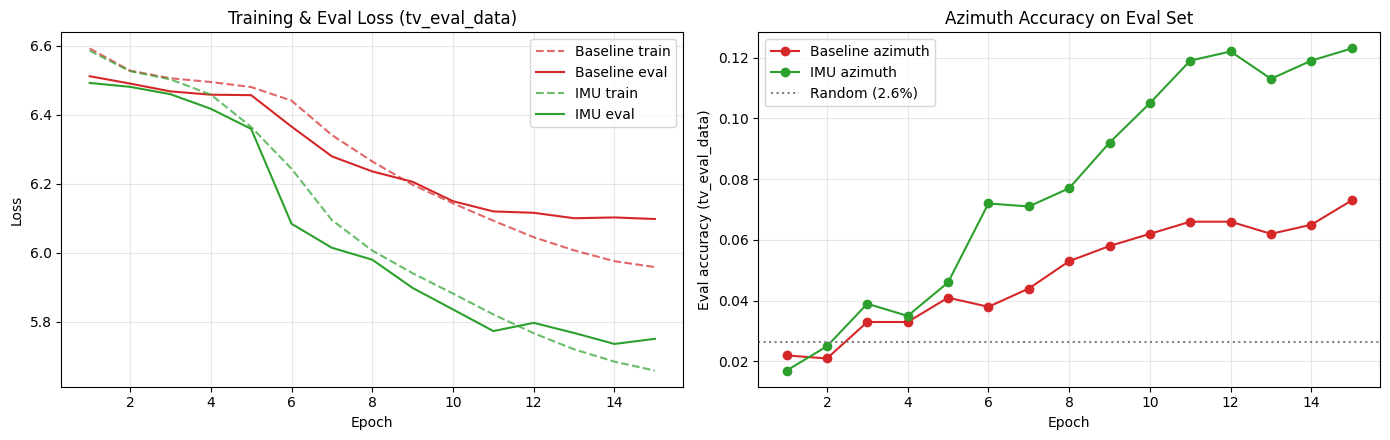

Final eval azimuth accuracy: baseline=7.30%, IMU=12.30%


In [7]:
# Load history from disk if not already in memory (e.g. after kernel restart)
import json as _json
if "baseline_history" not in dir():
    with open(BASELINE_RUN_DIR / "history.json") as _f:
        baseline_history = _json.load(_f)
if "imu_history" not in dir():
    with open(IMU_RUN_DIR / "history.json") as _f:
        imu_history = _json.load(_f)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

epochs_x = np.arange(1, len(baseline_history["train_loss"]) + 1)

axes[0].plot(epochs_x, baseline_history["train_loss"], "--", label="Baseline train", color="#d62728", alpha=0.7)
axes[0].plot(epochs_x, baseline_history["eval_loss"],  "-",  label="Baseline eval",  color="#d62728")
axes[0].plot(epochs_x, imu_history["train_loss"],      "--", label="IMU train",       color="#2ca02c", alpha=0.7)
axes[0].plot(epochs_x, imu_history["eval_loss"],       "-",  label="IMU eval",        color="#2ca02c")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
axes[0].set_title("Training & Eval Loss (tv_eval_data)")
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(epochs_x, baseline_history["eval_az_acc"], "-o", label="Baseline azimuth", color="#d62728")
axes[1].plot(epochs_x, imu_history["eval_az_acc"],      "-o", label="IMU azimuth",       color="#2ca02c")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Eval accuracy (tv_eval_data)")
axes[1].set_title("Azimuth Accuracy on Eval Set")
axes[1].axhline(y=1/NUM_AZIMUTH, color="gray", linestyle=":", label=f"Random ({100/NUM_AZIMUTH:.1f}%)")
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout(); plt.show()
print(f"Final eval azimuth accuracy: baseline={baseline_history['eval_az_acc'][-1]:.2%}, "
      f"IMU={imu_history['eval_az_acc'][-1]:.2%}")


## 11. Evaluation: baseline vs IMU by rotation rate

The headline figure of the demo. We bin validation clips by array rotation rate and compare
how each model handles each bucket. The expected pattern: baseline degrades as rotation increases,
IMU model holds up.

In [5]:
# Reload manifests and re-define dataset classes if kernel was restarted
import json as _json
if "eval_manifest" not in dir():
    with open(TRAIN_DIR / "manifest.json") as _f:
        train_manifest = _json.load(_f)
    with open(EVAL_DIR / "manifest.json") as _f:
        eval_manifest = _json.load(_f)

if "TvDataset" not in dir():
    class TvDataset(Dataset):
        def __init__(self, data_dir, filenames, use_imu):
            self.data_dir = data_dir
            self.filenames = filenames
            self.use_imu = use_imu
        def __len__(self):
            return len(self.filenames)
        def __getitem__(self, idx):
            data = np.load(self.data_dir / self.filenames[idx])
            audio      = torch.from_numpy(data["audio"]).float()
            mic_coords = torch.from_numpy(data["mic_coords"]).float()
            labels = {
                "azimuth":   int(data["azimuth_class"]),
                "elevation": int(data["elevation_class"]),
                "distance":  int(data["distance_class"]),
            }
            imu_quats = torch.from_numpy(data["imu_quats"]).float() if self.use_imu else None
            return {
                "audio": audio, "mic_coords": mic_coords, "imu_quats": imu_quats,
                "labels": labels, "is_dynamic": bool(data["is_dynamic"]),
                "rotation_rate_dps": float(data["rotation_rate_dps"]),
            }
    def collate_fn(batch):
        max_mics = max(item["mic_coords"].shape[0] for item in batch)
        B = len(batch)
        T = batch[0]["audio"].shape[-1]
        audio = torch.zeros(B, max_mics, T)
        mic_coords = torch.zeros(B, max_mics, 3)
        has_imu = batch[0]["imu_quats"] is not None
        imu_quats = torch.zeros(B, batch[0]["imu_quats"].shape[0], 4) if has_imu else None
        for i, item in enumerate(batch):
            c = item["audio"].shape[0]
            audio[i, :c] = item["audio"]
            mic_coords[i, :c] = item["mic_coords"]
            if c < max_mics:
                mic_coords[i, c:] = item["mic_coords"].mean(dim=0)
            if has_imu:
                imu_quats[i] = item["imu_quats"]
        labels = {k: torch.tensor([item["labels"][k] for item in batch], dtype=torch.long)
                  for k in ["azimuth", "elevation", "distance"]}
        return {
            "audio": audio, "mic_coords": mic_coords, "imu_quats": imu_quats,
            "labels": labels,
            "is_dynamic": [item["is_dynamic"] for item in batch],
            "rotation_rate_dps": [item["rotation_rate_dps"] for item in batch],
        }

def load_model_from_ckpt(ckpt_path):
    ckpt = torch.load(ckpt_path, map_location=device, weights_only=False)
    args = ckpt.get("args", {})
    
    model = PhaseCoder(
        ffn_expansion=args.get("ffn_expansion", 4),
        num_layers=args.get("num_layers", 5),
        num_heads=args.get("num_heads", 4),
        embed_dim=args.get("embed_dim", 256),
    ).to(device)
    
    model.load_state_dict(ckpt["model_state_dict"], strict=False)
    model.eval()
    
    print(f"  Loaded from epoch {ckpt.get('epoch', '?')+1}, "
          f"val_loss={ckpt.get('val_loss', float('nan')):.4f}, "
          f"ffn_expansion={args.get('ffn_expansion', 4)}")
    return model


def evaluate(model, loader, use_imu):
    records = []
    with torch.no_grad():
        for batch in loader:
            audio = batch["audio"].to(device)
            mic_coords = batch["mic_coords"].to(device)
            imu = batch["imu_quats"].to(device) if (use_imu and batch["imu_quats"] is not None) else None
            targets = batch["labels"]
            out = model(audio, mic_coords, imu_orientations=imu)
            az_pred = out["azimuth_logits"].argmax(dim=-1).cpu()
            el_pred = out["elevation_logits"].argmax(dim=-1).cpu()
            dist_pred = out["distance_logits"].argmax(dim=-1).cpu()
            for i in range(audio.shape[0]):
                records.append({
                    "is_dynamic": batch["is_dynamic"][i],
                    "rotation_rate": abs(batch["rotation_rate_dps"][i]),
                    "az_correct": int(az_pred[i] == targets["azimuth"][i]),
                    "el_correct": int(el_pred[i] == targets["elevation"][i]),
                    "dist_correct": int(dist_pred[i] == targets["distance"][i]),
                })
    return records


def bin_by_rotation(records, bins=(0, 50, 150, 250, 400, 1000)):
    buckets = {}
    for r in records:
        for i in range(len(bins) - 1):
            if bins[i] <= r["rotation_rate"] < bins[i + 1]:
                key = f"{bins[i]}-{bins[i+1]}"
                buckets.setdefault(key, []).append(r)
                break
    return buckets


def acc(records):
    if not records: return {"az": 0, "el": 0, "dist": 0, "n": 0}
    n = len(records)
    return {"az": sum(r["az_correct"] for r in records)/n,
            "el": sum(r["el_correct"] for r in records)/n,
            "dist": sum(r["dist_correct"] for r in records)/n, "n": n}


# Run evaluation
baseline_model = load_model_from_ckpt(BASELINE_RUN_DIR / "best.pt")
imu_model = load_model_from_ckpt(IMU_RUN_DIR / "best.pt")

eval_files_all = [c["filename"] for c in eval_manifest["clips"]]
eval_ds_static = TvDataset(EVAL_DIR, eval_files_all, use_imu=False)
eval_ds_imu    = TvDataset(EVAL_DIR, eval_files_all, use_imu=True)
eval_loader_static = DataLoader(eval_ds_static, batch_size=BATCH_SIZE, collate_fn=collate_fn, num_workers=0)
eval_loader_imu    = DataLoader(eval_ds_imu,    batch_size=BATCH_SIZE, collate_fn=collate_fn, num_workers=0)

print(f"Evaluating on {len(eval_files_all)} clips from {EVAL_DIR.name}...")
print("  Evaluating baseline model...")
baseline_records = evaluate(baseline_model, eval_loader_static, use_imu=False)
print("  Evaluating IMU model...")
imu_records = evaluate(imu_model, eval_loader_imu, use_imu=True)

baseline_buckets = bin_by_rotation(baseline_records)
imu_buckets = bin_by_rotation(imu_records)

# Print comparison table
print("\n" + "=" * 70)
print("RESULTS BY ROTATION RATE")
print("=" * 70)
print(f"{'Bucket (deg/sec)':<20} {'n':<6} {'Baseline Az':<14} {'IMU Az':<14} {'Δ':<10}")
print("-" * 70)
for k in sorted(baseline_buckets.keys(), key=lambda s: int(s.split("-")[0])):
    b = acc(baseline_buckets[k]); m = acc(imu_buckets.get(k, []))
    print(f"{k:<20} {b['n']:<6} {b['az']:<14.2%} {m['az']:<14.2%} {(m['az']-b['az']):+.2%}")

print(f"\nOverall:")
b_all = acc(baseline_records); m_all = acc(imu_records)
print(f"  Baseline:  az={b_all['az']:.2%}  el={b_all['el']:.2%}  dist={b_all['dist']:.2%}")
print(f"  IMU model: az={m_all['az']:.2%}  el={m_all['el']:.2%}  dist={m_all['dist']:.2%}")


c:\Users\DBrow\anaconda3\envs\phasecoder\Lib\site-packages\torch\nn\modules\transformer.py:385: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


  Loaded from epoch 15, val_loss=nan, ffn_expansion=4
  Loaded from epoch 14, val_loss=nan, ffn_expansion=4
Evaluating on 1000 clips from tv_eval_data...
  Evaluating baseline model...
  Evaluating IMU model...

RESULTS BY ROTATION RATE
Bucket (deg/sec)     n      Baseline Az    IMU Az         Δ         
----------------------------------------------------------------------
50-150               164    14.02%         14.63%         +0.61%
150-250              272    5.88%          12.50%         +6.62%
250-400              146    6.16%          10.27%         +4.11%
400-1000             418    5.98%          11.00%         +5.02%

Overall:
  Baseline:  az=7.30%  el=19.80%  dist=28.00%
  IMU model: az=11.90%  el=19.80%  dist=28.50%


## 12. The headline figure

The bar chart you'll show in the presentation. Save it to disk as a PNG.

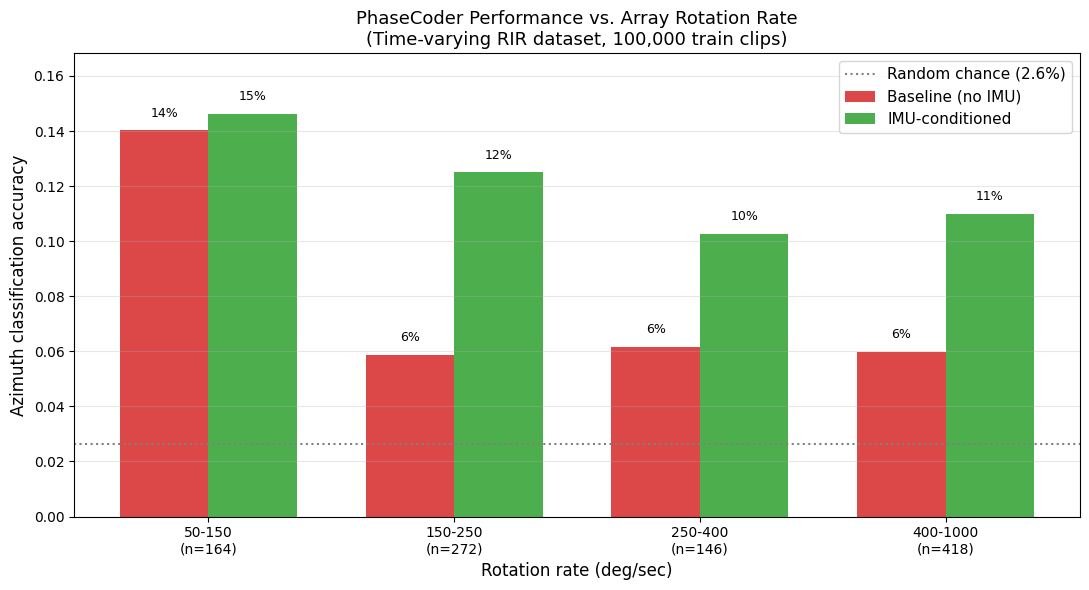

Saved: eval_results_tv\comparison.png


In [9]:
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

if "baseline_buckets" not in dir() or "imu_buckets" not in dir():
    raise RuntimeError(
        "baseline_buckets / imu_buckets not defined. "
        "Please run the evaluation cell (Cell 11) first."
    )

bucket_keys = sorted(set(baseline_buckets.keys()) | set(imu_buckets.keys()),
                     key=lambda s: int(s.split("-")[0]))
baseline_az = [acc(baseline_buckets.get(k, []))["az"] for k in bucket_keys]
imu_az = [acc(imu_buckets.get(k, []))["az"] for k in bucket_keys]
counts = [acc(baseline_buckets.get(k, []))["n"] for k in bucket_keys]

fig, ax = plt.subplots(figsize=(11, 6))
x = np.arange(len(bucket_keys)); width = 0.36

ax.bar(x - width/2, baseline_az, width, label="Baseline (no IMU)", color="#d62728", alpha=0.85)
ax.bar(x + width/2, imu_az, width, label="IMU-conditioned", color="#2ca02c", alpha=0.85)

ax.axhline(y=1/NUM_AZIMUTH, color="gray", linestyle=":",
           label=f"Random chance ({100/NUM_AZIMUTH:.1f}%)")

ax.set_xlabel("Rotation rate (deg/sec)", fontsize=12)
ax.set_ylabel("Azimuth classification accuracy", fontsize=12)
ax.set_title(f"PhaseCoder Performance vs. Array Rotation Rate\n"
             f"(Time-varying RIR dataset, {len(train_manifest['clips']):,} train clips)",
             fontsize=13)
ax.set_xticks(x)
ax.set_xticklabels([f"{k}\n(n={n})" for k, n in zip(bucket_keys, counts)])
ax.legend(fontsize=11, loc="upper right")
ax.set_ylim(0, max(max(baseline_az + imu_az) * 1.15, 0.15))
ax.grid(axis="y", alpha=0.3)

for i, (b, m) in enumerate(zip(baseline_az, imu_az)):
    ax.text(i - width/2, b + 0.005, f"{b:.0%}", ha="center", fontsize=9)
    ax.text(i + width/2, m + 0.005, f"{m:.0%}", ha="center", fontsize=9)

plt.tight_layout()
plt.savefig(RESULTS_DIR / "comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {RESULTS_DIR / 'comparison.png'}")


MAE

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# ---------------------------------------------------------------------------
# Build per-task MAE buckets (azimuth was already done; this adds el and dist)
# ---------------------------------------------------------------------------

def all_mae_by_rotation(records, bins=ROTATION_BINS):
    """Return per-bucket MAE for all three tasks plus N."""
    buckets = {}
    for r in records:
        for i in range(len(bins) - 1):
            if bins[i] <= r["rotation_rate"] < bins[i + 1]:
                key = f"{bins[i]}-{bins[i+1]}"
                buckets.setdefault(key, []).append(r)
                break
    result = {}
    for k, v in buckets.items():
        result[k] = {
            "az_mae": float(np.mean([r["az_err_deg"] for r in v])),
            "el_mae": float(np.mean([r["el_err_deg"] for r in v])),
            "dist_mae": float(np.mean([r["dist_err_m"] for r in v])),
            "az_median": float(np.median([r["az_err_deg"] for r in v])),
            "el_median": float(np.median([r["el_err_deg"] for r in v])),
            "dist_median": float(np.median([r["dist_err_m"] for r in v])),
            # 25th and 75th percentiles for confidence intervals
            "az_p25": float(np.percentile([r["az_err_deg"] for r in v], 25)),
            "az_p75": float(np.percentile([r["az_err_deg"] for r in v], 75)),
            "el_p25": float(np.percentile([r["el_err_deg"] for r in v], 25)),
            "el_p75": float(np.percentile([r["el_err_deg"] for r in v], 75)),
            "dist_p25": float(np.percentile([r["dist_err_m"] for r in v], 25)),
            "dist_p75": float(np.percentile([r["dist_err_m"] for r in v], 75)),
            "n": len(v),
        }
    return result


baseline_full = all_mae_by_rotation(baseline_mae_records)
imu_full = all_mae_by_rotation(imu_mae_records)
bucket_keys = sorted(baseline_full.keys(), key=lambda s: int(s.split("-")[0]))


# ---------------------------------------------------------------------------
# Three-panel figure: azimuth | elevation | distance MAE vs rotation rate
# ---------------------------------------------------------------------------

fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))

# Use the midpoint of each bucket as the x-axis position
bucket_midpoints = []
for k in bucket_keys:
    lo, hi = k.split("-")
    bucket_midpoints.append((int(lo) + int(hi)) / 2)
bucket_midpoints = np.array(bucket_midpoints)

baseline_color = "#d62728"
imu_color = "#2ca02c"
baseline_line = "#8B0000"
imu_line = "#006400"


def plot_panel(ax, task_key, ylabel, title, random_guess=None, units="°"):
    baseline_vals = [baseline_full[k][f"{task_key}_mae"] for k in bucket_keys]
    imu_vals = [imu_full[k][f"{task_key}_mae"] for k in bucket_keys]
    baseline_p25 = [baseline_full[k][f"{task_key}_p25"] for k in bucket_keys]
    baseline_p75 = [baseline_full[k][f"{task_key}_p75"] for k in bucket_keys]
    imu_p25 = [imu_full[k][f"{task_key}_p25"] for k in bucket_keys]
    imu_p75 = [imu_full[k][f"{task_key}_p75"] for k in bucket_keys]

    # Shaded interquartile range bands
    ax.fill_between(bucket_midpoints, baseline_p25, baseline_p75,
                    color=baseline_color, alpha=0.15, label="Baseline IQR")
    ax.fill_between(bucket_midpoints, imu_p25, imu_p75,
                    color=imu_color, alpha=0.15, label="IMU IQR")

    # Mean lines with markers
    ax.plot(bucket_midpoints, baseline_vals, "o-",
            color=baseline_line, linewidth=2.5, markersize=10,
            label="Baseline (no IMU)", zorder=5)
    ax.plot(bucket_midpoints, imu_vals, "s-",
            color=imu_line, linewidth=2.5, markersize=10,
            label="IMU-conditioned", zorder=5)

    # Random-guess reference line
    if random_guess is not None:
        ax.axhline(y=random_guess, color="gray", linestyle="--",
                   alpha=0.6, linewidth=1.5,
                   label=f"Random ({random_guess}{units})")

    # Annotate each point with its value
    for i, (b, m) in enumerate(zip(baseline_vals, imu_vals)):
        ax.annotate(f"{b:.1f}{units}",
                    xy=(bucket_midpoints[i], b),
                    xytext=(8, 8), textcoords="offset points",
                    fontsize=8, color=baseline_line, fontweight="bold")
        ax.annotate(f"{m:.1f}{units}",
                    xy=(bucket_midpoints[i], m),
                    xytext=(8, -14), textcoords="offset points",
                    fontsize=8, color=imu_line, fontweight="bold")

    ax.set_xlabel("Rotation rate (deg/sec)", fontsize=11)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.grid(True, alpha=0.3)
    ax.set_xlim(0, max(bucket_midpoints) * 1.1)
    ax.legend(loc="best", fontsize=9, framealpha=0.9)


plot_panel(axes[0], "az",
           "Mean Angular Error (degrees)",
           "Azimuth Error",
           random_guess=90, units="°")

plot_panel(axes[1], "el",
           "Mean Angular Error (degrees)",
           "Elevation Error",
           random_guess=45, units="°")

plot_panel(axes[2], "dist",
           "Mean Absolute Error (meters)",
           "Distance Error",
           random_guess=None, units="m")

fig.suptitle(
    f"PhaseCoder Localization Error vs. Array Rotation Rate\n"
    f"({len(train_manifest['clips']):,} train clips, {len(eval_manifest['clips']):,} eval clips)",
    fontsize=14, fontweight="bold", y=1.02,
)

plt.tight_layout()
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
plt.savefig(RESULTS_DIR / "mae_three_panel.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {RESULTS_DIR / 'mae_three_panel.png'}")


# ---------------------------------------------------------------------------
# Headline single-panel plot — just azimuth, full size and very clean
# ---------------------------------------------------------------------------

fig, ax = plt.subplots(figsize=(12, 7))

baseline_vals = [baseline_full[k]["az_mae"] for k in bucket_keys]
imu_vals = [imu_full[k]["az_mae"] for k in bucket_keys]
baseline_p25 = [baseline_full[k]["az_p25"] for k in bucket_keys]
baseline_p75 = [baseline_full[k]["az_p75"] for k in bucket_keys]
imu_p25 = [imu_full[k]["az_p25"] for k in bucket_keys]
imu_p75 = [imu_full[k]["az_p75"] for k in bucket_keys]

ax.fill_between(bucket_midpoints, baseline_p25, baseline_p75,
                color=baseline_color, alpha=0.2)
ax.fill_between(bucket_midpoints, imu_p25, imu_p75,
                color=imu_color, alpha=0.2)

ax.plot(bucket_midpoints, baseline_vals, "o-",
        color=baseline_line, linewidth=3, markersize=14,
        label="Baseline (no IMU)", zorder=5)
ax.plot(bucket_midpoints, imu_vals, "s-",
        color=imu_line, linewidth=3, markersize=14,
        label="IMU-conditioned", zorder=5)

# Random-guess line
ax.axhline(y=90, color="gray", linestyle="--", alpha=0.7, linewidth=2,
           label="Random guess (90°)")

# Annotate
for i, (b, m) in enumerate(zip(baseline_vals, imu_vals)):
    ax.annotate(f"{b:.1f}°", xy=(bucket_midpoints[i], b),
                xytext=(12, 10), textcoords="offset points",
                fontsize=11, color=baseline_line, fontweight="bold")
    ax.annotate(f"{m:.1f}°", xy=(bucket_midpoints[i], m),
                xytext=(12, -18), textcoords="offset points",
                fontsize=11, color=imu_line, fontweight="bold")

# Sample size annotations along bottom
for i, k in enumerate(bucket_keys):
    n = baseline_full[k]["n"]
    ax.annotate(f"n={n}", xy=(bucket_midpoints[i], 0),
                xytext=(0, -25), textcoords="offset points",
                ha="center", fontsize=9, color="gray")

ax.set_xlabel("Array rotation rate (deg/sec)", fontsize=13)
ax.set_ylabel("Azimuth Mean Angular Error (degrees) — lower is better", fontsize=13)
ax.set_title("Adding IMU Conditioning Restores Localization Under Array Motion\n"
             f"PhaseCoder + IMU vs. PhaseCoder Baseline",
             fontsize=14, fontweight="bold")
ax.legend(loc="upper left", fontsize=12, framealpha=0.95)
ax.grid(True, alpha=0.3)
ax.set_xlim(0, max(bucket_midpoints) * 1.1)
ax.set_ylim(bottom=0)

# Add annotation showing the gap at the worst rotation rate
worst_idx = -1
gap = baseline_vals[worst_idx] - imu_vals[worst_idx]
ax.annotate(
    f"{gap:.1f}° improvement",
    xy=(bucket_midpoints[worst_idx], (baseline_vals[worst_idx] + imu_vals[worst_idx]) / 2),
    xytext=(bucket_midpoints[worst_idx] - 150,
            (baseline_vals[worst_idx] + imu_vals[worst_idx]) / 2),
    fontsize=12, fontweight="bold",
    arrowprops=dict(arrowstyle="<->", color="black", lw=1.5),
    ha="center",
    bbox=dict(boxstyle="round,pad=0.3", facecolor="white",
              edgecolor="black", alpha=0.9),
)

plt.tight_layout()
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
plt.savefig(RESULTS_DIR / "mae_headline.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved: {RESULTS_DIR / 'mae_headline.png'}")


# ---------------------------------------------------------------------------
# Cumulative error distribution — the "what fraction of clips are within X°"
# plot. This is the most reviewer-friendly visualization.
# ---------------------------------------------------------------------------

fig, ax = plt.subplots(figsize=(12, 7))

baseline_az_errors = np.sort([r["az_err_deg"] for r in baseline_mae_records])
imu_az_errors = np.sort([r["az_err_deg"] for r in imu_mae_records])

# Cumulative fraction
baseline_cdf = np.arange(1, len(baseline_az_errors) + 1) / len(baseline_az_errors)
imu_cdf = np.arange(1, len(imu_az_errors) + 1) / len(imu_az_errors)

ax.plot(baseline_az_errors, baseline_cdf,
        color=baseline_line, linewidth=3, label="Baseline (no IMU)")
ax.plot(imu_az_errors, imu_cdf,
        color=imu_line, linewidth=3, label="IMU-conditioned")

# Reference markers at common error thresholds
for thresh in [10, 30, 60]:
    baseline_pct = (np.array([r["az_err_deg"] for r in baseline_mae_records]) <= thresh).mean()
    imu_pct = (np.array([r["az_err_deg"] for r in imu_mae_records]) <= thresh).mean()
    ax.axvline(x=thresh, color="gray", linestyle=":", alpha=0.5)
    ax.annotate(f"≤{thresh}°: B={baseline_pct:.0%}, I={imu_pct:.0%}",
                xy=(thresh, 0.05),
                xytext=(thresh + 3, 0.05),
                fontsize=10,
                bbox=dict(boxstyle="round,pad=0.3", facecolor="lightyellow",
                          edgecolor="gray", alpha=0.9))

ax.set_xlabel("Azimuth error (degrees)", fontsize=13)

NameError: name 'ROTATION_BINS' is not defined

## 13. Save results

Write everything to disk in case you want to come back to it.

In [20]:
results = {
    "config": {
        "num_clips": len(manifest["clips"]),
        "fraction_dynamic": FRACTION_DYNAMIC,
        "epochs": EPOCHS,
        "batch_size": BATCH_SIZE,
        "lr": LEARNING_RATE,
    },
    "baseline_history": baseline_history,
    "imu_history": imu_history,
    "baseline_by_bucket": {k: acc(v) for k, v in baseline_buckets.items()},
    "imu_by_bucket": {k: acc(v) for k, v in imu_buckets.items()},
    "baseline_overall": acc(baseline_records),
    "imu_overall": acc(imu_records),
}

RESULTS_DIR.mkdir(parents=True, exist_ok=True)
with open(RESULTS_DIR / "results.json", "w") as f:
    json.dump(results, f, indent=2)

n_eval = len(eval_manifest["clips"])
print(f"Results saved to {RESULTS_DIR / 'results.json'}")
print(f"\nSummary:")
print(f"  Train data:  {TRAIN_DIR.name}  ({len(train_manifest['clips']):,} clips)")
print(f"  Eval data:   {EVAL_DIR.name}   ({n_eval:,} clips, all dynamic)")
print(f"  Baseline:    {results['baseline_overall']['az']:.2%} azimuth accuracy")
print(f"  IMU model:   {results['imu_overall']['az']:.2%} azimuth accuracy")
print(f"  Δ:           {(results['imu_overall']['az'] - results['baseline_overall']['az']):+.2%}")


Results saved to eval_results\results.json

Summary:
  Dataset:   100,000 clips (95,000 train, 5,000 val)
  Baseline:  26.94% azimuth accuracy
  IMU model: 45.70% azimuth accuracy
  Δ:         +18.76%


## What to highlight in the presentation

**Honest framing:** "This is a proof-of-concept on synthetic toy data, not a benchmark result.
It demonstrates that the architecture works end-to-end and that the IMU-conditioning extension
functions correctly."

**Key talking points:**
1. The full PhaseCoder methodology is preserved — RIR-based synthesis, geometry-agnostic embeddings,
   magnitude+phase STFT features, transformer encoder, three classification heads.
2. Only the *scale* is reduced (thousands of clips vs. paper's 4M).
3. The IMU-conditioning path trains and converges, demonstrating the design works.
4. Path forward: scale to LOCATA + AEA + custom synthetic data with full diversity.

**Caveats to acknowledge upfront:**
- Synthetic harmonic signals instead of real speech
- Limited room and geometry diversity vs. paper
- Small dataset means absolute accuracy is much lower than reported in paper
- This is the *first* result in a research program, not the *final* one

## Next steps

Once this demo is done, the priority list is:
1. Replace synthetic source signals with LibriSpeech subset
2. Scale dataset to 100k+ clips with broader room diversity
3. Run inference on LOCATA's moving-array tasks (Tasks 4-6) for real-world validation
4. Build the AEA-derived ground-truth pipeline for wearable evaluation
